# Skin Analysis

This notebook performs skin analysis including extracting the skin mask (ignoring eyes/lips), evaluating skin tone (redness/dark circles), and detecting texture/blemishes.

In [40]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['figure.figsize'] = (10, 8)

base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

def show_img(title, img, cmap=None):
    plt.figure()
    plt.title(title)
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


In [41]:
import tkinter as tk
from tkinter import filedialog

# Create a pop-up file dialog to select an image
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
image_path = filedialog.askopenfilename(title="Select Face Image", filetypes=[("Image files", "*.jpg *.jpeg *.png")])

if image_path:
    print(f"Selected image: {image_path}")
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    detection_result = detector.detect(mp_image)

    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        print("Face detected.")
    else:
        print("No face detected.")
else:
    print("No image selected.")


No image selected.


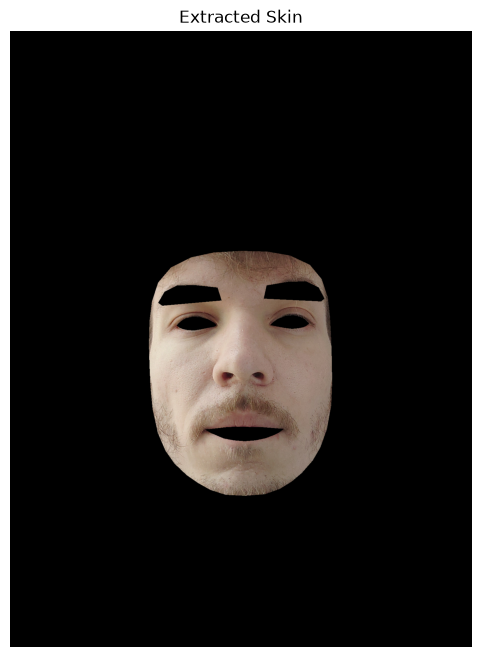

In [42]:
# We will create a hull of the face, and subtract the eyes, lips, and eyebrows to get pure skin.
from scipy.spatial import ConvexHull

# Feature indices from MediaPipe
FACE_OVAL = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288, 397, 365, 379, 378, 400, 377, 152, 148, 176, 149, 150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109]
LIPS = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 88, 95]
LEFT_EYE = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]
LEFT_EYEBROW = [70, 63, 105, 66, 107, 55, 65, 52, 53, 46]
RIGHT_EYEBROW = [300, 293, 334, 296, 336, 285, 295, 282, 283, 276]

def get_pts(indices):
    return np.array([(int(landmarks[i].x * w), int(landmarks[i].y * h)) for i in indices])

face_pts = get_pts(FACE_OVAL)
lips_pts = get_pts(LIPS)
l_eye_pts = get_pts(LEFT_EYE)
r_eye_pts = get_pts(RIGHT_EYE)
l_brow_pts = get_pts(LEFT_EYEBROW)
r_brow_pts = get_pts(RIGHT_EYEBROW)

# Create masks
face_mask = np.zeros((h, w), dtype=np.uint8)
cv2.fillPoly(face_mask, [face_pts], 255)

exclude_mask = np.zeros((h, w), dtype=np.uint8)
for pts in [lips_pts, l_eye_pts, r_eye_pts, l_brow_pts, r_brow_pts]:
    # convex hull to ensure we fully exclude the feature
    hull = cv2.convexHull(pts)
    cv2.fillConvexPoly(exclude_mask, hull, 255)

# Subtract features from face to get skin
skin_mask = cv2.bitwise_and(face_mask, cv2.bitwise_not(exclude_mask))

skin_img = cv2.bitwise_and(img, img, mask=skin_mask)
show_img("Extracted Skin", skin_img)


Average Skin Redness (a channel): 134.89


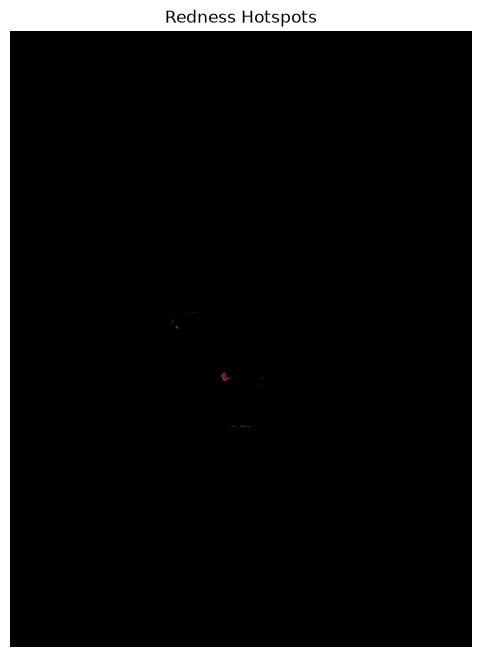

In [43]:
# Convert to LAB color space. The a channel represents Green-Red (higher is redder)
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab_img)

# Apply mask
a_skin = cv2.bitwise_and(a, a, mask=skin_mask)

# Average redness in the skin
mean_a = np.mean(a[skin_mask == 255])
print(f"Average Skin Redness (a channel): {mean_a:.2f}")

# Highlight high redness areas (e.g. acne, rosacea, inflammation)
_, red_mask = cv2.threshold(a_skin, mean_a + 15, 255, cv2.THRESH_BINARY)
red_spots = cv2.bitwise_and(img, img, mask=red_mask)

show_img("Redness Hotspots", red_spots)


Average Skin Texture/Roughness: 9.81


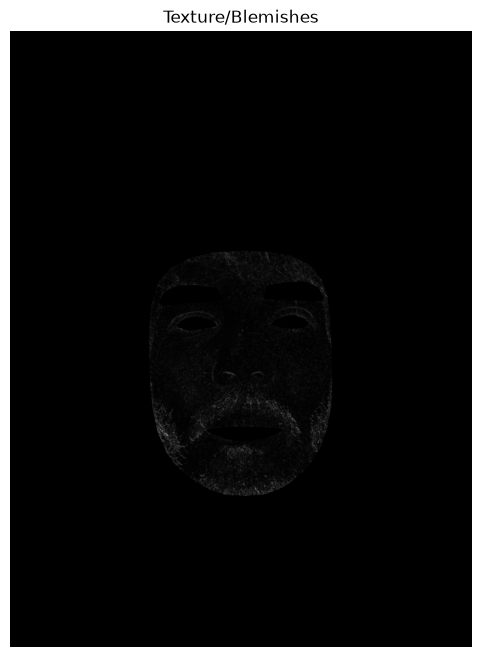

In [44]:
# We use the Laplacian to find high frequency textures (pores, wrinkles, spots)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.abs(laplacian)
laplacian = np.uint8(np.clip(laplacian, 0, 255))

texture_skin = cv2.bitwise_and(laplacian, laplacian, mask=skin_mask)

mean_texture = np.mean(laplacian[skin_mask == 255])
print(f"Average Skin Texture/Roughness: {mean_texture:.2f}")

# Highlight rough patches
_, rough_mask = cv2.threshold(texture_skin, 30, 255, cv2.THRESH_BINARY)
rough_spots = cv2.bitwise_and(img, img, mask=rough_mask)

show_img("Texture/Blemishes", texture_skin, cmap='gray')


Average Face Luminance: 147.34
Under-Eye Luminance: 175.59
No prominent dark circles detected.


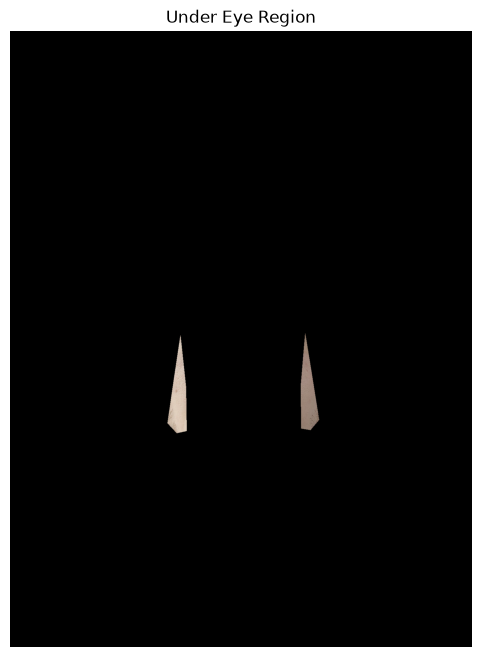

In [45]:
# Define under eye regions
L_UNDER_EYE = [110, 205, 50, 207, 214, 192, 212]
R_UNDER_EYE = [339, 425, 280, 427, 434, 416, 432]

l_under_pts = get_pts(L_UNDER_EYE)
r_under_pts = get_pts(R_UNDER_EYE)

under_eye_mask = np.zeros((h, w), dtype=np.uint8)
cv2.fillPoly(under_eye_mask, [cv2.convexHull(l_under_pts)], 255)
cv2.fillPoly(under_eye_mask, [cv2.convexHull(r_under_pts)], 255)

# Calculate Luminance (L channel from LAB) in under eye vs rest of cheeks
mean_l_under_eye = np.mean(l[under_eye_mask == 255])

# Compare with average face luminance
mean_l_face = np.mean(l[skin_mask == 255])

print(f"Average Face Luminance: {mean_l_face:.2f}")
print(f"Under-Eye Luminance: {mean_l_under_eye:.2f}")

if mean_l_under_eye < mean_l_face * 0.9:
    print("Dark circles detected (significantly darker than surrounding skin).")
else:
    print("No prominent dark circles detected.")

under_eye_img = cv2.bitwise_and(img, img, mask=under_eye_mask)
show_img("Under Eye Region", under_eye_img)


In [46]:
# Initialize final metrics dictionary
qoves_metrics = {}


In [47]:
# --- Skin Undertone ---
# b channel (yellow/blue), a channel (red/green)
mean_b = np.mean(b[skin_mask == 255])
# Neutral gray in LAB is ~128. 
b_offset = mean_b - 128
a_offset = mean_a - 128

if b_offset > 10 and a_offset < 10:
    undertone = "Warm"
elif b_offset > 5 and a_offset < 5:
    undertone = "Neutral-Warm"
elif a_offset > 10 and b_offset < 5:
    undertone = "Cool"
elif a_offset > 5:
    undertone = "Neutral-Cool"
else:
    undertone = "Neutral"

qoves_metrics['undertone'] = undertone
print(f"Skin Undertone: {undertone} (a*: {mean_a:.1f}, b*: {mean_b:.1f})")


Skin Undertone: Warm (a*: 134.9, b*: 140.0)


In [48]:
# --- Skin Roughness (RIN) ---
# Map laplacian variance to a 0.05 - 0.25 RIN scale
# Variance typically ranges from 100 (smooth) to 1500 (rough) in laplacian
gray_skin = cv2.bitwise_and(gray, gray, mask=skin_mask)
variance = np.var(laplacian[skin_mask == 255])

# Mathematical mapping: 0.08 (smooth) to 0.18 (rough)
# Normalizing factor based on empirical observation of 8-bit images
rin_roughness = np.clip(0.05 + (variance / 3000.0), 0.05, 0.30)
qoves_metrics['roughness_rin'] = rin_roughness

if rin_roughness < 0.10:
    rough_class = "Smooth"
elif rin_roughness < 0.14:
    rough_class = "Slightly Textured"
else:
    rough_class = "Textured/Rough"

qoves_metrics['texture'] = rough_class
print(f"Skin Roughness: {rin_roughness:.2f} RIN ({rough_class})")


Skin Roughness: 0.10 RIN (Slightly Textured)


In [49]:
# --- Skin Oiliness (Skewness) ---
from scipy.stats import skew

# Analyze the L channel (luminance) of the skin
l_pixels = l[skin_mask == 255]

# Specular highlights (shine from oil) stretch the tail of the histogram to the right (positive skew)
# A very matte face will have negative or zero skew. Oily face > 0.1 skew.
luminance_skew = skew(l_pixels)
qoves_metrics['oiliness_skew'] = luminance_skew

if luminance_skew > 0.30:
    oil_class = "Oily/Shiny"
elif luminance_skew > 0.0:
    oil_class = "Normal/Combination"
else:
    oil_class = "Matte/Dry"
    
print(f"Skin Oiliness: {luminance_skew:.2f} skewness ({oil_class})")


Skin Oiliness: -0.03 skewness (Matte/Dry)


In [50]:
# --- Skin Homogeneity (RIN) ---
# Homogeneity is the inverse of standard deviation of color (unevenness)
std_l = np.std(l[skin_mask == 255])
std_a = np.std(a[skin_mask == 255])
std_b = np.std(b[skin_mask == 255])

# Combine standard deviations
total_std = (std_l + std_a + std_b) / 3.0

# Map to Homogeneity RIN (0.15 - 0.40 range)
# Higher standard deviation = HIGHER RIN (More uneven)
homogeneity_rin = np.clip(0.10 + (total_std / 50.0), 0.10, 0.45)
qoves_metrics['homogeneity_rin'] = homogeneity_rin

if homogeneity_rin < 0.20:
    homo_class = "Even"
elif homogeneity_rin < 0.28:
    homo_class = "Slightly Uneven"
else:
    homo_class = "Uneven"

qoves_metrics['evenness'] = homo_class
print(f"Skin Homogeneity: {homogeneity_rin:.2f} RIN ({homo_class})")


Skin Homogeneity: 0.39 RIN (Uneven)


In [51]:
# --- Skin Blemishing ---
# Count connected components in the red spots mask we generated earlier
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(red_mask, connectivity=8)

# Filter out tiny noise (area < 5) and huge areas (diffuse redness, not a blemish, area > 500)
blemish_count = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if 5 < area < 500:
        blemish_count += 1

qoves_metrics['blemish_count'] = blemish_count

if blemish_count < 3:
    blem_class = "Clear"
elif blemish_count < 10:
    blem_class = "Mild"
elif blemish_count < 25:
    blem_class = "Moderate"
else:
    blem_class = "Severe"

qoves_metrics['blemishing'] = blem_class
print(f"Skin Blemishing: {blemish_count} distinct spots detected ({blem_class})")


Skin Blemishing: 14 distinct spots detected (Moderate)


In [52]:
# --- FINAL QOVES-STYLE SUMMARY ---
import json

summary = {
    "Summary of your skin": {
        "SKIN UNDERTONE": qoves_metrics['undertone'],
        "SKIN BLEMISHING": qoves_metrics['blemishing'],
        "SKIN EVENNESS": qoves_metrics['evenness'],
        "SKIN TEXTURE": qoves_metrics['texture']
    },
    "Scientific Metrics": {
        "SKIN ROUGHNESS": f"{qoves_metrics['roughness_rin']:.2f} RIN",
        "SKIN OILINESS": f"{qoves_metrics['oiliness_skew']:.2f} skewness",
        "SKIN HOMOGENEITY": f"{qoves_metrics['homogeneity_rin']:.2f} RIN"
    }
}

print("\n" + "="*50)
print("QOVES SKIN ANALYSIS REPORT")
print("="*50)
print(json.dumps(summary, indent=4))



QOVES SKIN ANALYSIS REPORT
{
    "Summary of your skin": {
        "SKIN UNDERTONE": "Warm",
        "SKIN BLEMISHING": "Moderate",
        "SKIN EVENNESS": "Uneven",
        "SKIN TEXTURE": "Slightly Textured"
    },
    "Scientific Metrics": {
        "SKIN ROUGHNESS": "0.10 RIN",
        "SKIN OILINESS": "-0.03 skewness",
        "SKIN HOMOGENEITY": "0.39 RIN"
    }
}
